In [1]:

import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io 
import mne
import os
import sys

epoch_path = "E:/workspace/kiki_conformity_data/Trust_Clean2" # 分析哪个roi就输入哪个文件夹的数据
behavior_path = "E:/workspace/kiki_conformity_data/Find_trials_combine" # 分析哪个roi就输入哪个文件夹的数据

subjects = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

# subjects = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

len(subjects)

channel_location_dict = {"Fp1":	[-26.25, 83, -18.25],
"Fp2": [26.25, 83, -18.25],
"F3": [-48.75, 57.5, 36.5],
"F4": [48.75, 57.5, 36.5],
"C3": [-63.75, -13, 65.75],
"C4": [63.75, -13, 65.75],
"P3": [-48, -86.5, 53],
"P4": [48, -86.5, 53],
"O1": [-27, -118, 4.25],
"O2": [27, -118, 4.25],
"F7": [-69, 44, -18.25],
"F8": [69, 44, -18.25],
"T7": [-84, -18.25, -13],
"T8": [84, -18.25, -13],
"P7": [-69, -80.5, -4.75],
"P8": [69, -80.5, -4.75],
"Fz": [0, 63.5, 59],
"Cz": [0, -10, 99.5],
"Pz": [0, -88, 77],
"FC1": [-32.25, 28.25, 77.75],
"FC2": [32.25, 28.25, 77.75],
"CP1": [-35.25, -52, 90.5],
"CP2": [35.25, -52, 90.5],
"FC5": [-75.75, 20, 21.5],
"FC6": [75.75, 20, 21.5],
"CP5": [-78, -51.25, 31.25],
"CP6": [78, -51.25, 31.25],
"FT9": [-72.75, 8.75, -55.75],
"FT10": [72.75, 8.75, -55.75],
"TP9": [-71.25, -49, -49.75],
"TP10": [71.25, -49, -49.75],
"F1": [-25.5, 62, 53.75],
"F2": [25.5, 62, 53.75],
"C1": [-35.25, -11.5, 89.75],
"C2": [35.25, -11.5, 89.75],
"P1": [-27, -88, 70.25],
"P2": [27, -88, 70.25],
"AF3": [-32.25, 80.75, 11.75],
"AF4": [32.25, 80.75, 11.75],
"FC3": [-59.25, 25.25, 54.5],
"FC4": [59.25, 25.25, 54.5],
"CP3": [-63, -52, 66.5],
"CP4": [63, -52, 66.5],
"PO3": [-31.5, -109.75, 32.75],
"PO4": [31.5, -109.75, 32.75],
"F5": [-63, 51.5, 11.75],
"F6": [63, 51.5, 11.75],
"C5": [-81.75, -14.5, 29],
"C6": [81.75, -14.5, 29],
"P5": [-63.75, -83.5, 26.75],
"P6": [63.75, -83.5, 26.75],
"AF7": [-50.25, 68, -19],
"AF8": [50.25, 68, -19],
"FT7": [-79.5, 15.5, -16],
"FT8": [79.5, 15.5, -16],
"TP7": [-80.25, -49.75, -8.5],
"TP8": [80.25, -49.75, -8.5],
"PO7": [-50.25, -103, 0.5],
"PO8": [50.25, -103, 0.5],
"Fpz": [0, 83, -18.25],
"CPz": [0, -53.5, 98],
"POz": [0, -109, 44],
"Oz": [0, -122.5, 8]}
# ['Fp1', 'Fp2', 'Fz', 'Cz', 'Pz', 'Fpz', 'CPz', 'POz', 'Oz'].
mymontage = mne.channels.make_dig_montage(ch_pos=channel_location_dict)#, nasion=[0, -10, 99.5], lpa=[-71.25, -49, -49.75], 
#                                        rpa=[71.25, -49, -49.75])

In [55]:
#个体水平
from mne.time_frequency import tfr_morlet
from pathlib import Path

freqs=np.arange(4, 8, 1)
# freqs=np.arange(8, 13, 1)
# freqs=np.arange(13, 30, 1)

# n_cycles = 10
n_cycles=freqs/4  # 4
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:  # 2
        n_cycles[i] = 2 # 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10


# n_cycles =4
time_span = 100
ch_names = []
decision_time_range = [-1.0, 5] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s


all_sub_human_data = []
all_sub_AI_data = []
human_trial_num, AI_trial_num = 0, 0


    # 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path,verbose=False)  # 允许多个事件编号
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    # 降采样
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # task3_data = behavior_trial[behavior_trial["task"].astype(str) == "30"]
    print(len(behavior_trial))

    # 提取不同条件是第几个试次

    # 1. 筛选task列值为10的行
    # task_10_rows = behavior_trial[behavior_trial['image_type'] == 308]
    task_30_human = behavior_trial[behavior_trial['image_type'] == 308]
    task_30_AI = behavior_trial[behavior_trial['image_type'] == 309]

    human_indices = task_30_human.index.tolist()  # 正差组的行索引
    ai_indices = task_30_AI.index.tolist()  # 负差组的行索引

    # 统一计算tfr
    all_human_trials_mean_tfr = tfr_morlet(EEG_epochs[human_indices], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)  # lower
    all_AI_trials_mean_tfr = tfr_morlet(EEG_epochs[ai_indices], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)   # higher

    # 基线校正
    all_human_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_AI_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio

    # 计算 Human 试次的平均 TFR
    human_mean_tfr = np.mean(all_human_trials_mean_tfr.data, axis=1)  # 计算平均值
    AI_mean_tfr = np.mean(all_AI_trials_mean_tfr.data, axis=1)

    # 存入 list，而不是 `append` 到 `AverageTFR` 对象
    all_sub_human_data.append(human_mean_tfr)
    all_sub_AI_data.append(AI_mean_tfr)  # 确保变量名与列表匹配




<ipython-input-55-d0067dd00b32>:34: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path,verbose=False)  # 允许多个事件编号
<ipython-input-55-d0067dd00b32>:37: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  14 tasks      | elapsed:    0.7s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.8s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
<ipython-input-55-d0067dd00b32>:34: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path,verbose=False)  # 允许多个事件编号
<ipython-input-55-d0067dd00b32>:37: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


...

[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
<ipython-input-55-d0067dd00b32>:34: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path,verbose=False)  # 允许多个事件编号
<ipython-input-55-d0067dd00b32>:37: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  24 tasks      | elapsed:    0.0s


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished


In [ ]:
#接收到social influence时的活动
from mne.time_frequency import tfr_morlet
from pathlib import Path

freqs=np.arange(4, 8, 1)
# freqs=np.arange(8, 13, 1)
# freqs=np.arange(13, 30, 1)

# n_cycles = 10
n_cycles=freqs/4  # 4
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:  # 2
        n_cycles[i] = 2 # 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10


# n_cycles =4
time_span = 100
ch_names = []
# 1. 定义时间窗口（feedback_time 对齐后）
tmin, tmax = -0.2, 1.0  # 单位：秒（-200ms 到 +1000ms）



all_sub_human_data = []
all_sub_AI_data = []
human_trial_num, AI_trial_num = 0, 0
tmin, tmax = -0.2, 1.0  # 单位：秒（-200ms 到 +1000ms）


# 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)  # 允许多个事件编号
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    # 降采样
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # task3_data = behavior_trial[behavior_trial["task"].astype(str) == "30"]
    # print(len(behavior_trial))

    # 提取不同条件是第几个试次

    # 1. 筛选task列值为10的行
    task_10_rows = behavior_trial[behavior_trial['image_type'] == 308]
    # task_10_rows = behavior_trial[behavior_trial['image_type'] == 309]

    # 2. 提取rating列并排序
    ratings_sorted = task_10_rows['rating'].sort_values(ascending=False).values

    # 2. rating列减去30
    task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30

    # 3. 计算grouprating减去调整后的rating
    task_10_rows['difference'] = task_10_rows['grouprating'] - task_10_rows['rating_adjusted']

    # 4. 分为正差和负差两组
    positive_diff_rows = task_10_rows[task_10_rows['difference'] > 0]  # 差值为正的行
    negative_diff_rows = task_10_rows[task_10_rows['difference'] < 0]  # 差值为负的行

    positive_indices = positive_diff_rows.index.tolist()  # 正差组的行索引
    negative_indices = negative_diff_rows.index.tolist()  # 负差组的行索引
    # print(positive_indices)
    if not positive_indices or not negative_indices:
        continue  # 跳过本次循环
    # 2. 提取两组 trials 的 feedback_time
    positive_fbt = behavior_trial.loc[positive_indices, 'feedback_time'].values / 1000  # 转秒
    negative_fbt = behavior_trial.loc[negative_indices, 'feedback_time'].values / 1000  # 转秒

    # 统一计算tfr
    all_human_trials_mean_tfr = tfr_morlet(EEG_epochs[negative_indices], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=5, verbose=False)  # lower
    all_AI_trials_mean_tfr = tfr_morlet(EEG_epochs[positive_indices], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=5, verbose=False)   # higher

    # 基线校正
    all_human_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_AI_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio


    # 计算偏移的水平
    human_mean_tfr_alter = []
    AI_mean_tfr_alter = []
    for iter_trial in range(len(all_human_trials_mean_tfr.data)):
        # iter_trial_time = positive_fbt[iter_trial] + 1) * 
        human_mean_tfr_alter.append(all_human_trials_mean_tfr[iter_trial].crop(negative_fbt[iter_trial]-0.2, negative_fbt[iter_trial]+1).data)

    for iter_trial in range(len(all_AI_trials_mean_tfr.data)):
        # iter_trial_time = positive_fbt[iter_trial] + 1) * 
        AI_mean_tfr_alter.append(all_AI_trials_mean_tfr[iter_trial].crop(positive_fbt[iter_trial]-0.2, positive_fbt[iter_trial]+1).data)

    human_mean_tfr_alter = np.squeeze(human_mean_tfr_alter)
    AI_mean_tfr_alter = np.squeeze(AI_mean_tfr_alter)
    human_mean_tfr_alter = np.array(human_mean_tfr_alter)
    AI_mean_tfr_alter = np.array(AI_mean_tfr_alter)
    if human_mean_tfr_alter.ndim == 3:
        human_mean_tfr_alter =  human_mean_tfr_alter[np.newaxis, ...]  # (1, 63, 42, 42)

    if AI_mean_tfr_alter.ndim == 3:
        AI_mean_tfr_alter =  AI_mean_tfr_alter[np.newaxis, ...]  # (1, 63, 42, 42)
        
    # 计算 Human 频谱的平均 TFR
    human_mean_tfr_alter = np.mean(human_mean_tfr_alter, axis=2)  # 计算平均值
    AI_mean_tfr_alter = np.mean(AI_mean_tfr_alter, axis=2)

    # 计算 Human 试次平均
    human_mean_tfr_alter = np.mean(human_mean_tfr_alter, axis=0)  # 计算平均值
    AI_mean_tfr_alter = np.mean(AI_mean_tfr_alter, axis=0)


    # 存入 list，而不是 `append` 到 `AverageTFR` 对象
    all_sub_human_data.append(human_mean_tfr_alter)
    all_sub_AI_data.append(AI_mean_tfr_alter)  # 确保变量名与列表匹配




<ipython-input-29-67dc4a294ef3>:36: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)  # 允许多个事件编号
<ipython-input-29-67dc4a294ef3>:39: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)
<ipython-input-29-67dc4a294ef3>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30
<ipython-input-29-67dc4a294ef3>:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-29-67dc4a294ef3>:36: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)  # 允许多个事件编号
<ipython-input-29-67dc4a294ef3>:39: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-29-67dc4a294ef3>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30
<ipython-input-29-67dc4a294ef3>:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['difference'] = task_10_rows['grouprating'] - task_10_rows['rating_adjusted']
<ipython-input-29-67dc4a294ef3>:36: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, v

...

<ipython-input-29-67dc4a294ef3>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30
<ipython-input-29-67dc4a294ef3>:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['difference'] = task_10_rows['grouprating'] - task_10_rows['rating_adjusted']
<ipython-input-29-67dc4a294ef3>:36: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, v

Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-29-67dc4a294ef3>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30
<ipython-input-29-67dc4a294ef3>:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['difference'] = task_10_rows['grouprating'] - task_10_rows['rating_adjusted']
<ipython-input-29-67dc4a294ef3>:36: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, v

Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-29-67dc4a294ef3>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30
<ipython-input-29-67dc4a294ef3>:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['difference'] = task_10_rows['grouprating'] - task_10_rows['rating_adjusted']


In [37]:
#先对epoch进行剪切
from mne.time_frequency import tfr_morlet
from pathlib import Path
import numpy as np
import pandas as pd
import mne

freqs = np.arange(4, 8, 1)
n_cycles = freqs / 4
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:
        n_cycles[i] = 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10

# Define time window around feedback_time (before performing TFR)
pre_feedback = 0.6  # time before feedback to include (600ms)
post_feedback = 1.1  # time after feedback to include (1100ms)

all_sub_human_data = []
all_sub_AI_data = []

# 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)

    # 提取不同条件是第几个试次
    task_30_human = behavior_trial[behavior_trial['image_type'] == 308]
    task_30_AI = behavior_trial[behavior_trial['image_type'] == 309]

    human_indices = task_30_human.index.tolist()  # 正差组的行索引
    ai_indices = task_30_AI.index.tolist()  # 负差组的行索引
    
    if not human_indices or not ai_indices:
        continue

    # 获取两组 trials 的 feedback_time (in seconds)
    human_fbt = behavior_trial.loc[human_indices, 'feedback_time'].values / 1000
    ai_fbt = behavior_trial.loc[ai_indices, 'feedback_time'].values / 1000

    ################ 对齐human
    # 将列表转换为 numpy 数组以便处理 nan
    human_indices_arr = np.array(human_indices)
    human_fbt_arr = np.array(human_fbt)

    # 找出两个数组中不是 nan 的索引
    valid_mask = ~np.isnan(human_indices_arr) & ~np.isnan(human_fbt_arr)

    # 应用掩码过滤两个数组
    human_indices = human_indices_arr[valid_mask].tolist()
    human_fbt = human_fbt_arr[valid_mask].tolist()


    ##### chuli AI
    # 将列表转换为 numpy 数组以便处理 nan
    ai_indices_arr = np.array(ai_indices)
    ai_fbt_arr = np.array(ai_fbt)

    # 找出两个数组中不是 nan 的索引
    valid_mask = ~np.isnan(ai_indices_arr) & ~np.isnan(ai_fbt_arr)

    # 应用掩码过滤两个数组
    ai_indices = ai_indices_arr[valid_mask].tolist()
    ai_fbt = ai_fbt_arr[valid_mask].tolist()

    # Function to create aligned epochs for each trial
    def create_aligned_epochs(epochs, indices, feedback_times):
        aligned_data = []
        for idx, fb_time in zip(indices, feedback_times):
            # Get the original epoch data (shape: (1, n_channels, n_times))
            epoch_data = epochs[idx].get_data()
            
            # Find the time point corresponding to feedback_time
            tmin_original = epochs.times[0]
            feedback_sample = int((fb_time - tmin_original) * epochs.info['sfreq'])
            
            # Calculate new crop boundaries
            start_sample = feedback_sample - int(pre_feedback * epochs.info['sfreq'])
            end_sample = feedback_sample + int(post_feedback * epochs.info['sfreq'])
            
            # Check if crop boundaries are valid
            if start_sample < 0 or end_sample > epoch_data.shape[-1]:
                print(f"Skipping trial {idx} - crop out of bounds")
                continue
            
            # Crop the data around feedback_time (keep channel dimension)
            cropped_data = epoch_data[:, :, start_sample:end_sample]  # shape: (1, n_channels, n_samples)
            aligned_data.append(cropped_data)
        
        if not aligned_data:
            print("No valid trials after alignment")
            return None
    
        # Combine all trials (shape: (n_trials, n_channels, n_samples))
        combined_data = np.concatenate(aligned_data, axis=0)
        
        # Create new epochs object with aligned data
        aligned_epochs = mne.EpochsArray(
            data=combined_data,
            info=epochs.info,
            tmin=-pre_feedback,
            # events=np.zeros((len(aligned_data), 3)),  # dummy events
            verbose=False
        )
        return aligned_epochs

    # Create aligned epochs for both conditions
    human_aligned_epochs = create_aligned_epochs(EEG_epochs, human_indices, human_fbt)
    AI_aligned_epochs = create_aligned_epochs(EEG_epochs, ai_indices, ai_fbt)

    # Skip if no valid epochs
    if human_aligned_epochs is None or AI_aligned_epochs is None:
        continue

    # Perform time-frequency analysis on aligned epochs
    human_tfr = tfr_morlet(
        human_aligned_epochs, 
        freqs, 
        n_cycles=n_cycles, 
        return_itc=False, 
        average=True,  # Don't average across trials yet
        use_fft=True, 
        n_jobs=5, 
        verbose=False
    )
    
    AI_tfr = tfr_morlet(
        AI_aligned_epochs, 
        freqs, 
        n_cycles=n_cycles, 
        return_itc=False, 
        average=True,  # Don't average across trials yet
        use_fft=True, 
        n_jobs=5, 
        verbose=False
    )

    # Apply baseline correction (-0.5 to 0 relative to feedback time)
    human_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0))
    AI_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0))

    # Crop to final time window of interest (-0.5 to 1s)

    human_tfr.crop(-0.5,1)
    AI_tfr.crop(-0.5,1)
    
    # Average across channels if needed (remove this if you want to keep channel dimension)
    human_mean_tfr = np.mean(human_tfr.data, axis=1)  # shape: (n_freqs, n_times)
    AI_mean_tfr = np.mean(AI_tfr.data, axis=1)

    # Store results
    all_sub_human_data.append(human_mean_tfr)
    all_sub_AI_data.append(AI_mean_tfr)

<ipython-input-37-eed5e3c55582>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-37-eed5e3c55582>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-37-eed5e3c55582>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-37-eed5e3c55582>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-37-eed5e3c55582>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-37-eed5e3c55582>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


...

Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-37-eed5e3c55582>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-37-eed5e3c55582>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-37-eed5e3c55582>:27: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, verbose=False)
<ipython-input-37-eed5e3c55582>:30: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


In [34]:
ai_fbt = behavior_trial.loc[ai_indices, 'feedback_time'].values / 1000


In [32]:
np.array(ai_fbt)

array([0.726938, 0.732922, 0.75237 , 0.763338, 0.77492 , 0.780004,
       0.79222 , 0.803588, 0.820368, 0.826936, 0.832752, 0.860002,
       0.889184, 0.906402, 0.917416, 0.9228  , 0.934068, 0.939198,
       0.951266])

In [36]:
ai_indices

[159,
 160,
 163,
 165,
 167,
 168,
 170,
 172,
 175,
 176,
 177,
 181,
 186,
 189,
 191,
 192,
 194,
 195,
 197]

In [35]:
ai_fbt 

array([0.726938, 0.732922, 0.75237 , 0.763338, 0.77492 , 0.780004,
       0.79222 , 0.803588, 0.820368, 0.826936, 0.832752, 0.860002,
       0.889184, 0.906402, 0.917416, 0.9228  , 0.934068, 0.939198,
       0.951266])

In [33]:
ai_fbt

array([0.726938, 0.732922, 0.75237 , 0.763338, 0.77492 , 0.780004,
       0.79222 , 0.803588, 0.820368, 0.826936, 0.832752, 0.860002,
       0.889184, 0.906402, 0.917416, 0.9228  , 0.934068, 0.939198,
       0.951266])

In [56]:
import mne
from mne.channels import find_ch_adjacency
from mne.datasets import sample
from mne.stats import combine_adjacency, spatio_temporal_cluster_test
from mne.viz import plot_compare_evokeds



# create a new epochs info
info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

# create a new ROI based epochs
all_sub_human_epoch = mne.EpochsArray(data = all_sub_human_data, info = info, tmin=-0.5)
all_sub_AI_epoch = mne.EpochsArray(data = all_sub_AI_data, info = info, tmin=-0.5)

# all_sub_imminent_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
# all_sub_moderate_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
all_sub_human_epoch.set_montage(mymontage)
all_sub_AI_epoch.set_montage(mymontage)

adjacency, ch_names = find_ch_adjacency(all_sub_human_epoch.info, ch_type="eeg")

print(type(adjacency))  # it's a sparse matrix!

all_sub_human_epoch.resample(100)
all_sub_AI_epoch.resample(100)


# all_sub_human_epoch = all_sub_human_epoch.crop(-0.5, 1)
# all_sub_AI_epoch = all_sub_AI_epoch.crop(-0.5, 1)

all_sub_human_epoch.apply_baseline(baseline = (-0.5,0))
all_sub_AI_epoch.apply_baseline(baseline = (-0.5,0)) 


Not setting metadata
Not setting metadata
38 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
38 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63


<ipython-input-56-03f74008a104>:18: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_human_epoch.set_montage(mymontage)
<ipython-input-56-03f74008a104>:19: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_AI_epoch.set_montage(mymontage)


<class 'scipy.sparse.csr.csr_matrix'>
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


Number of events,38
Events,1: 38
Time range,-0.500 – 5.590 sec
Baseline,-0.500 – 0.000 sec


In [19]:
import pandas as pd
import glob
import ast
from ast import literal_eval
import os
import numpy as np
# from supply import *

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *

#获取所有文件的地址
behavior_path = "E:/workspace/kiki_conformity_data/" # 分析哪个roi就输入哪个文件夹的数据

all_sub_behavior_result = pd.read_csv(behavior_path + '/model_result.csv')

In [20]:

def spatio_temporal_permutation_test_for_correlations_multi_regression(
    regress_data,
    regressors_design_matrix,
    adjacency,
    p_thresh,
    tail=0,
    n_perm=5000,
):
    res = mne.stats.linear_regression(regress_data, regressors_design_matrix, names=None)

    results = {name: {'t_maps': None, 'clusters': None, 'pvalues': None, 'cluster_stats_H0': []} 
               for name in res.keys() if name != "x0"}

    # Original t and p maps
    for name in results.keys():
        t_maps = res[name].t_val.data.transpose()
        p_maps = res[name].p_val.data.transpose()
        results[name]['t_maps'] = t_maps

        # Find original clusters
        clusters, cluster_stats_orig = find_clusters(t_maps, p_maps, adjacency, p_thresh, tail)
        results[name]['clusters'] = clusters
        results[name]['cluster_stats_orig'] = cluster_stats_orig

    # Permutation tests
    for _ in range(n_perm):
        regressors_design_matrix_perm = regressors_design_matrix.copy()
        np.random.shuffle(regressors_design_matrix_perm[:, 1:])  # Shuffle all regressors except the intercept
        res_perm = mne.stats.linear_regression(regress_data, regressors_design_matrix_perm, names=None)

        for name in results.keys():
            p_maps_perm = res_perm[name].p_val.data.transpose()
            t_maps_perm = res_perm[name].t_val.data.transpose()

            _, cluster_stats = find_clusters(t_maps_perm, p_maps_perm, adjacency, p_thresh, tail)

            if cluster_stats:
                if tail == 1:
                    results[name]['cluster_stats_H0'].append(max(cluster_stats))
                elif tail == -1:
                    results[name]['cluster_stats_H0'].append(min(cluster_stats))
                else:
                    results[name]['cluster_stats_H0'].append(max(map(abs, cluster_stats)))
            else:
                results[name]['cluster_stats_H0'].append(0)

    # Compute p-values
    for name in results.keys():
        pvalues = []
        for cluster_stat_orig in results[name]['cluster_stats_orig']:
            pvalues.append(compute_cluster_p_value(cluster_stat_orig, results[name]['cluster_stats_H0'], tail))
        results[name]['pvalues'] = pvalues

    # Store the full regression result
    results['res'] = res

    return results

In [70]:
# just for on condition
# 生成多张图片

all_sub_human_epoch_copy = all_sub_human_epoch.copy().crop(-0., 0.5)
all_sub_ai_epoch_copy = all_sub_AI_epoch.copy().crop(-0., 0.5) # vmpfc(0, 1.1)


sys.path.insert(0, 'E:/workspace/my_py_toolbox/electrode_time_cluster_permute_regress/')
from etcpr_stats import *
# 通过对比involve_time和epoch的时间序列来找到是第几位数字开始计算相关性

regress_data = all_sub_ai_epoch_copy
adjacency, ch_names = mne.channels.find_ch_adjacency(regress_data.info, ch_type="eeg")


iter_behavior_variability_1 = np.array(all_sub_behavior_result['ai_mean'])  # ai_mean h_mean

# design_matrix = np.vstack((np.ones(38), iter_behavior_variability_3))

design_matrix = np.vstack((np.ones(38), iter_behavior_variability_1))
design_matrix = np.transpose(design_matrix)
from sklearn.preprocessing import StandardScaler

# 标准化 后结果更好一些
scaler = StandardScaler()
# design_matrix[:, 1:] = scaler.fit_transform(design_matrix[:, 1:])

results =  spatio_temporal_permutation_test_for_correlations_multi_regression(
    regress_data,
    design_matrix,
    adjacency,
    p_thresh=0.05,
    tail=0,
    n_perm=10000,
    )

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitting linear model to epochs, (3213 targets, 2 regressors)
Done
Fitt

In [71]:
print(results['x1']['pvalues'])
# print(results['x2']['pvalues'])
# print(results['x3']['pvalues'])
# print(results['x4']['pvalues'])

[0.9987, 0.0712, 0.8725, 0.998, 0.9999, 0.9597, 0.905]


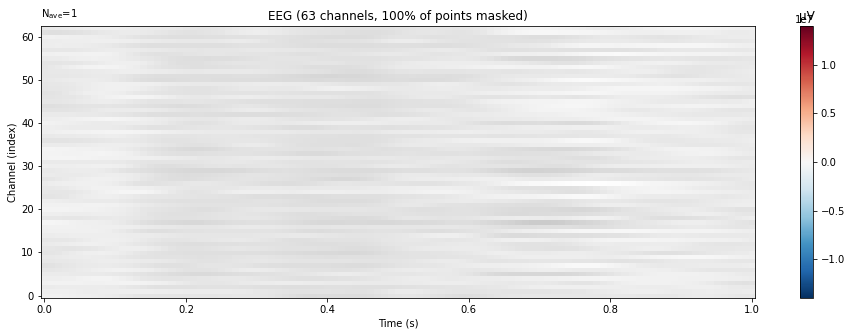

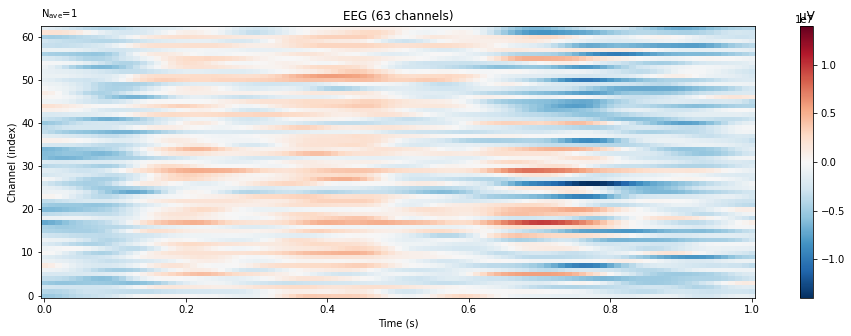

In [66]:
# plt.close('all')
import matplotlib.pyplot as plt
res = results['res']
all_mask = np.full(res["x1"].p_val.data.shape, False)
clusters = results['x1']['clusters']
# all_mask[clusters[0][1], clusters[0][0]] = True
# all_mask[clusters[13][1], clusters[13][0]] = True

evoked = res["x1"].beta
fig, axes = plt.subplots(figsize=(16,5))
# plt.rcParams['figure.figsize'] = (20,12) # 设置figure_size尺寸

fig = evoked.plot_image(axes=axes, mask=all_mask, time_unit='s')#, xlim=[-0.05, 0.2])
fig, axes = plt.subplots(figsize=(16,5))

fig = evoked.plot_image(axes=axes, time_unit='s')#, xlim=[-0.05, 0.2])

# plt.set_size_inches(10)
# fig.savefig(iter_figure_result_loc + str(iter_times) + '_' + str(times) + '_pic.png')

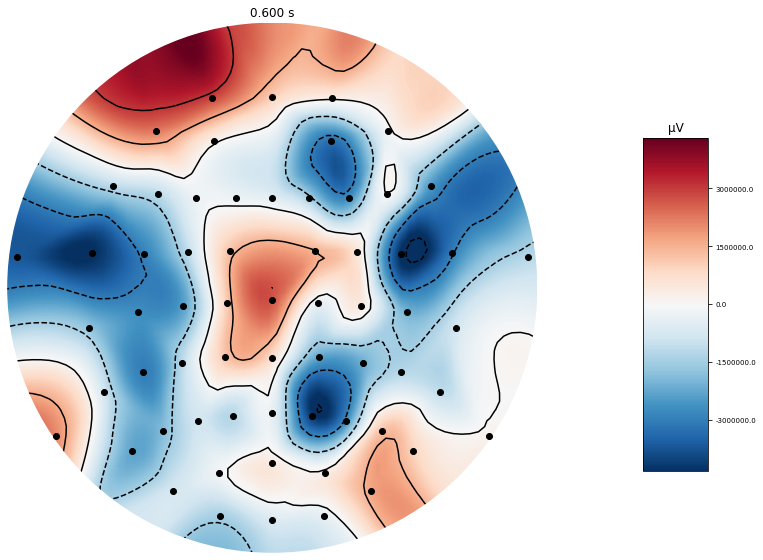

In [69]:
import matplotlib.pyplot as plt
plt.close('all')
times = 0.6

timepoint = int(times * 100 + 0)

all_mask = np.full(res["x1"].p_val.data.shape, False)
# all_mask[clusters[7][1], clusters[7][0]] = True
# all_mask[clusters[1][1], clusters[1][0]] = True

#time_mask = np.squeeze(all_mask[:,timepoint])

fig = evoked.plot_topomap(
    mask = all_mask, 
    outlines='head',
    times=times, 
    size=6, 
    show_names=False, 
    cmap='RdBu_r',
    # vmin=-600000,
    # vmax=600000,
    scalings=None, 
    sensors='ko',
    # sphere=0.13,
    # extrapolate='head',
    colorbar=True,
    mask_params=dict(marker='o',markersize=5, markerfacecolor='black')
    )# cmap GnBu
# fig.savefig(r'E:\workspace\Trust_Data_and_Results\Haoming\varibility\result\regression_result\pre_post_exp1_condition1\0.1.png')